In [55]:
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import sys

print("Done.")

Done.


In [56]:
option_print = True 

params = ["Ua","Ui","Ga","Gi","Da","Di","Ba"] # feature parameters to use
colors = ["red","green","blue","purple","orange","black","pink", "magenta", "turquoise", "cyan", "olive", "brown", "lime", "teal", "khaki", "fuchsia", "navy", "maroon", "gold", "coral"] # colors for each class
num_PCA_components = 2 # number of PCA components to use

pd.set_option('display.max_columns', None)

In [57]:
file_in = "data/unclassified_features_39517_KM_classes_6_s42_cutoff_0.85"


with open(file_in + ".pkl", 'rb') as f:
  feats_df_large = pickle.load(f) # deserialize using load()

print("\n", file_in, " shape: ", feats_df_large.shape)

# these unclassified images are from the proper parameter range
file_in_narrow = "data/unclassified_features_33770"

with open(file_in_narrow + ".pkl", 'rb') as f:
  df_narrow = pickle.load(f)

print("\n", file_in_narrow, " shape: ", df_narrow.shape)


 data/unclassified_features_39517_KM_classes_6_s42_cutoff_0.85  shape:  (33770, 42)

 data/unclassified_features_33770  shape:  (33770, 111)


In [58]:
# Create output directories

output_dir = "data/output_images/"
os.makedirs(output_dir, exist_ok=True)

output_sub_dir = output_dir + file_in[5:] + "/"
os.makedirs(output_sub_dir, exist_ok=True)

specific_file_dir = output_sub_dir + "Visualization_Features_Parameters/"
os.makedirs(specific_file_dir, exist_ok=True)

In [59]:
# we eliminate all images that are outside the narrow distribution
feats_df = feats_df_large[feats_df_large["path"].isin(df_narrow["path"].unique())]
feats_df.reset_index(inplace = True, drop = True)

print("\nFiltered feats_df with class and narrow bounds: ", feats_df.shape)
feats_df.head()


Filtered feats_df with class and narrow bounds:  (33770, 42)


,Ua,Ui,Ga,Gi,Ba,Da,Di,pattern,noise,path,seed,dir,feat_bool,num_spots,X_mean,Y_mean,Angle_mean,Circ._mean,%Area_mean,%Area_std,FeretAngle_mean,MinFeret_std,AR_std,Round_std,Solidity_mean,Solidity_std,num_spots_inverted,X_inverted_mean,Y_inverted_mean,Angle_inverted_mean,IntDen_inverted_mean,%Area_inverted_mean,%Area_inverted_std,FeretAngle_inverted_mean,MinFeret_inverted_std,AR_inverted_mean,AR_inverted_std,Solidity_inverted_mean,Solidity_inverted_std,pc1,pc2,cluster
0,0.02512,0.06382,0.07196,0.10633,-0.11313,0.00919,0.61187,1,2,1.png,1,/content/Images3/,1,70,99.39594,97.53023,55.10890,0.95869,100.00000,0.00000,120.12900,0.56478,0.18357,0.11537,0.87949,0.06714,1,99.99800,100.02200,38.79600,9980445.00000,100.00000,0.00000,45.00000,0.00000,1.00100,0.00000,0.97900,0.00000,2.25388,1.40257,0
1,0.03447,0.05996,0.08080,0.10037,-0.13258,0.00885,0.85408,1,2,3.png,3,/content/Images3/,1,63,101.80057,99.45127,56.04956,0.99962,100.00000,0.00000,120.19119,0.61353,0.22678,0.12798,0.95490,0.04641,1,99.99200,100.01500,72.38000,10003140.00000,100.00000,0.00000,135.00000,0.00000,1.00000,0.00000,0.98100,0.00000,1.32589,1.70848,0
2,0.02837,0.05791,0.07400,0.08078,-0.13379,0.00851,0.53424,1,2,7.png,7,/content/Images3/,1,77,100.55768,98.10334,29.22083,0.99297,100.00000,0.00000,133.45013,0.37595,0.22079,0.12952,0.94681,0.05097,1,99.98700,100.00100,5.76600,10012320.00000,100.00000,0.00000,45.00000,0.00000,1.00000,0.00000,0.98200,0.00000,1.27351,1.48869,0
3,0.03636,0.05572,0.08897,0.10772,-0.12676,0.01132,0.80970,1,2,11.png,11,/content/Images3/,1,60,100.27892,96.62343,31.87688,0.99860,100.00000,0.00000,121.10033,0.64010,0.25534,0.14752,0.87972,0.05249,1,99.99600,100.05800,126.21500,10042920.00000,100.00000,0.00000,135.00000,0.00000,1.00000,0.00000,0.98500,0.00000,1.90843,1.80442,0
4,0.03585,0.07876,0.07823,0.10148,-0.11575,0.01054,0.93389,1,2,12.png,12,/content/Images3/,1,73,103.19297,99.32097,58.91552,0.99763,100.00000,0.00000,110.34084,0.73139,0.18829,0.11005,0.91281,0.03712,1,99.97200,100.01500,57.70800,9882780.00000,100.00000,0.00000,135.00000,0.00000,1.00000,0.00000,0.96900,0.00000,1.54761,1.68752,0


In [60]:
# number of classes in clustering
if "cluster" in feats_df.columns:
    num_classes = len(feats_df["cluster"].unique()) 
    print("number of classes: ", num_classes)
else:
    print("Warning: no column called 'cluster' in dataframe")
    

number of classes:  6


In [61]:
classes = np.arange(0,num_classes)# list of unique clusters

class_dfs = [] # list of dfs for each cluster

feats_df = feats_df.copy()
for i in ["Ua","Ui","Ga","Gi","Da","Di","Ba"]:
    feats_df[i] = feats_df[i].astype(float)

for i in classes:
    df = feats_df[feats_df["cluster"] == i]
    df.reset_index(inplace = True, drop = True)
    class_dfs.append(df)

    print("Images in class ", i, ": ", class_dfs[i].shape)

Images in class  0 :  (10960, 42)
Images in class  1 :  (10938, 42)
Images in class  2 :  (9431, 42)
Images in class  3 :  (859, 42)
Images in class  4 :  (602, 42)
Images in class  5 :  (980, 42)


In [62]:
feats_df[feats_df.columns[13:111]].columns

Index(['num_spots', 'X_mean', 'Y_mean', 'Angle_mean', 'Circ._mean',
       '%Area_mean', '%Area_std', 'FeretAngle_mean', 'MinFeret_std', 'AR_std',
       'Round_std', 'Solidity_mean', 'Solidity_std', 'num_spots_inverted',
       'X_inverted_mean', 'Y_inverted_mean', 'Angle_inverted_mean',
       'IntDen_inverted_mean', '%Area_inverted_mean', '%Area_inverted_std',
       'FeretAngle_inverted_mean', 'MinFeret_inverted_std', 'AR_inverted_mean',
       'AR_inverted_std', 'Solidity_inverted_mean', 'Solidity_inverted_std',
       'pc1', 'pc2', 'cluster'],
      dtype='object')

In [63]:
df_analytics = feats_df.copy()
df_analytics = df_analytics[["Ua", "Ui", "Ga", "Gi", "Da", "Di", "Ba", "path", "dir", "cluster"]]

def tr(Ga_value, Ua_value, Ui_value):
    return Ga_value - Ua_value - Ui_value

def det(Ba_value, Gi_value, Ga_value, Ui_value, Ua_value):
    return -Ba_value * Gi_value - Ui_value * (Ga_value-Ua_value)

def T1(Di_value, Ga_value, Ua_value, Da_value, Ui_value):
    return Di_value * (Ga_value - Ua_value) - Da_value * Ui_value

def T2(Di_value, Gi_value, Ga_value, Ua_value, Da_value, Ui_value, Ba_value):
    return (Di_value * (Ga_value - Ua_value) - Da_value * Ui_value) ** 2 - 4 * Da_value * Di_value * det(Ba_value, Gi_value, Ga_value, Ui_value, Ua_value)


# compute these 4 analytics for each image and add to the dataframe
df_analytics["tr"] = df_analytics.apply(lambda row: tr(row["Ga"], row["Ua"], row["Ui"]), axis=1)
df_analytics["det"] = df_analytics.apply(lambda row: det(row["Ba"], row["Gi"], row["Ga"], row["Ui"], row["Ua"]), axis=1)
df_analytics["T1"] = df_analytics.apply(lambda row: T1(row["Di"], row["Ga"], row["Ua"], row["Da"], row["Ui"]), axis=1)
df_analytics["T2"] = df_analytics.apply(lambda row: T2(row["Di"], row["Gi"], row["Ga"], row["Ua"], row["Da"], row["Ui"], row["Ba"]), axis=1)

print("shape: ", df_analytics.shape)
df_analytics.head(25)

shape:  (33770, 14)


,Ua,Ui,Ga,Gi,Da,Di,Ba,path,dir,cluster,tr,det,T1,T2
0,0.02512,0.06382,0.07196,0.10633,0.00919,0.61187,-0.11313,1.png,/content/Images3/,0,-0.01699,0.00904,0.02807,0.00058
1,0.03447,0.05996,0.08080,0.10037,0.00885,0.85408,-0.13258,3.png,/content/Images3/,0,-0.01363,0.01053,0.03903,0.00121
2,0.02837,0.05791,0.07400,0.08078,0.00851,0.53424,-0.13379,7.png,/content/Images3/,0,-0.01228,0.00817,0.02389,0.00042
3,0.03636,0.05572,0.08897,0.10772,0.01132,0.80970,-0.12676,11.png,/content/Images3/,0,-0.00312,0.01072,0.04196,0.00137
4,0.03585,0.07876,0.07823,0.10148,0.01054,0.93389,-0.11575,12.png,/content/Images3/,0,-0.03638,0.00841,0.03875,0.00117
5,0.02984,0.06730,0.07905,0.09510,0.00972,0.82242,-0.13286,13.png,/content/Images3/,0,-0.01808,0.00932,0.03982,0.00129
6,0.03261,0.06648,0.07132,0.09421,0.00892,0.63797,-0.13740,14.png,/content/Images3/,2,-0.02777,0.01037,0.02410,0.00034
7,0.02378,0.07953,0.07507,0.08444,0.00820,0.88257,-0.12491,15.png,/content/Images3/,0,-0.02824,0.00647,0.04461,0.00180
8,0.01928,0.10584,0.15752,0.04695,0.00811,0.50356,-0.13294,17.png,/content/Images3/,1,0.03240,-0.00839,0.06875,0.00486
9,0.02564,0.06778,0.07865,0.11779,0.00854,0.61570,-0.13301,18.png,/content/Images3/,0,-0.01476,0.01207,0.03206,0.00077


In [64]:
# print the number of images with positive values for each analytic, by class

# create the presentation order
presentation_order = [2,0,5,3,4,1]

# old order for 0.85 cutoff on 39500 images: [1,0,2,3,5,4]
presentation_names = ["No pattern","Reg. spots","Tiger stripes","Inv. tiger stripes","Inverse spots","Full coverage"]

analytics = ["tr", "det", "T1", "T2"]

for i,name in enumerate(presentation_names):
    print("\nClass: " + name)
    cluster_id = presentation_order[i]
    cluster_df = df_analytics[df_analytics["cluster"] == cluster_id]
    cluster_n = cluster_df.shape[0]
    conditions = {
    "tr < 0": cluster_df["tr"] < 0,
    "det > 0": cluster_df["det"] > 0,
    "T1 > 0": cluster_df["T1"] > 0,
    "T2 > 0": cluster_df["T2"] > 0,
    }

    for label, mask in conditions.items():
        num_images = mask.sum()
        print(f'# {label}: {num_images} images')

    print()

    for label, mask in conditions.items():
        percent_images = mask.mean() * 100
        print(f'% {label}: {percent_images:.2f}% of this class')

    turing_mask = (
                (cluster_df["tr"] < 0) &
                (cluster_df["det"] > 0) &
                (cluster_df["T1"] > 0) &
                (cluster_df["T2"] > 0)
                )
    all_turing = turing_mask.sum()
    print(f"\n --- # satisfying all Turing conditions: {all_turing} images")
    print(f" --- % satisfying all Turing conditions: {turing_mask.mean()*100:.2f}% of this class")



Class: No pattern
# tr < 0: 7173 images
# det > 0: 9431 images
# T1 > 0: 7904 images
# T2 > 0: 4446 images

% tr < 0: 76.06% of this class
% det > 0: 100.00% of this class
% T1 > 0: 83.81% of this class
% T2 > 0: 47.14% of this class

 --- # satisfying all Turing conditions: 2214 images
 --- % satisfying all Turing conditions: 23.48% of this class

Class: Reg. spots
# tr < 0: 7375 images
# det > 0: 10941 images
# T1 > 0: 10960 images
# T2 > 0: 10960 images

% tr < 0: 67.29% of this class
% det > 0: 99.83% of this class
% T1 > 0: 100.00% of this class
% T2 > 0: 100.00% of this class

 --- # satisfying all Turing conditions: 7366 images
 --- % satisfying all Turing conditions: 67.21% of this class

Class: Tiger stripes
# tr < 0: 602 images
# det > 0: 919 images
# T1 > 0: 980 images
# T2 > 0: 980 images

% tr < 0: 61.43% of this class
% det > 0: 93.78% of this class
% T1 > 0: 100.00% of this class
% T2 > 0: 100.00% of this class

 --- # satisfying all Turing conditions: 542 images
 --- %

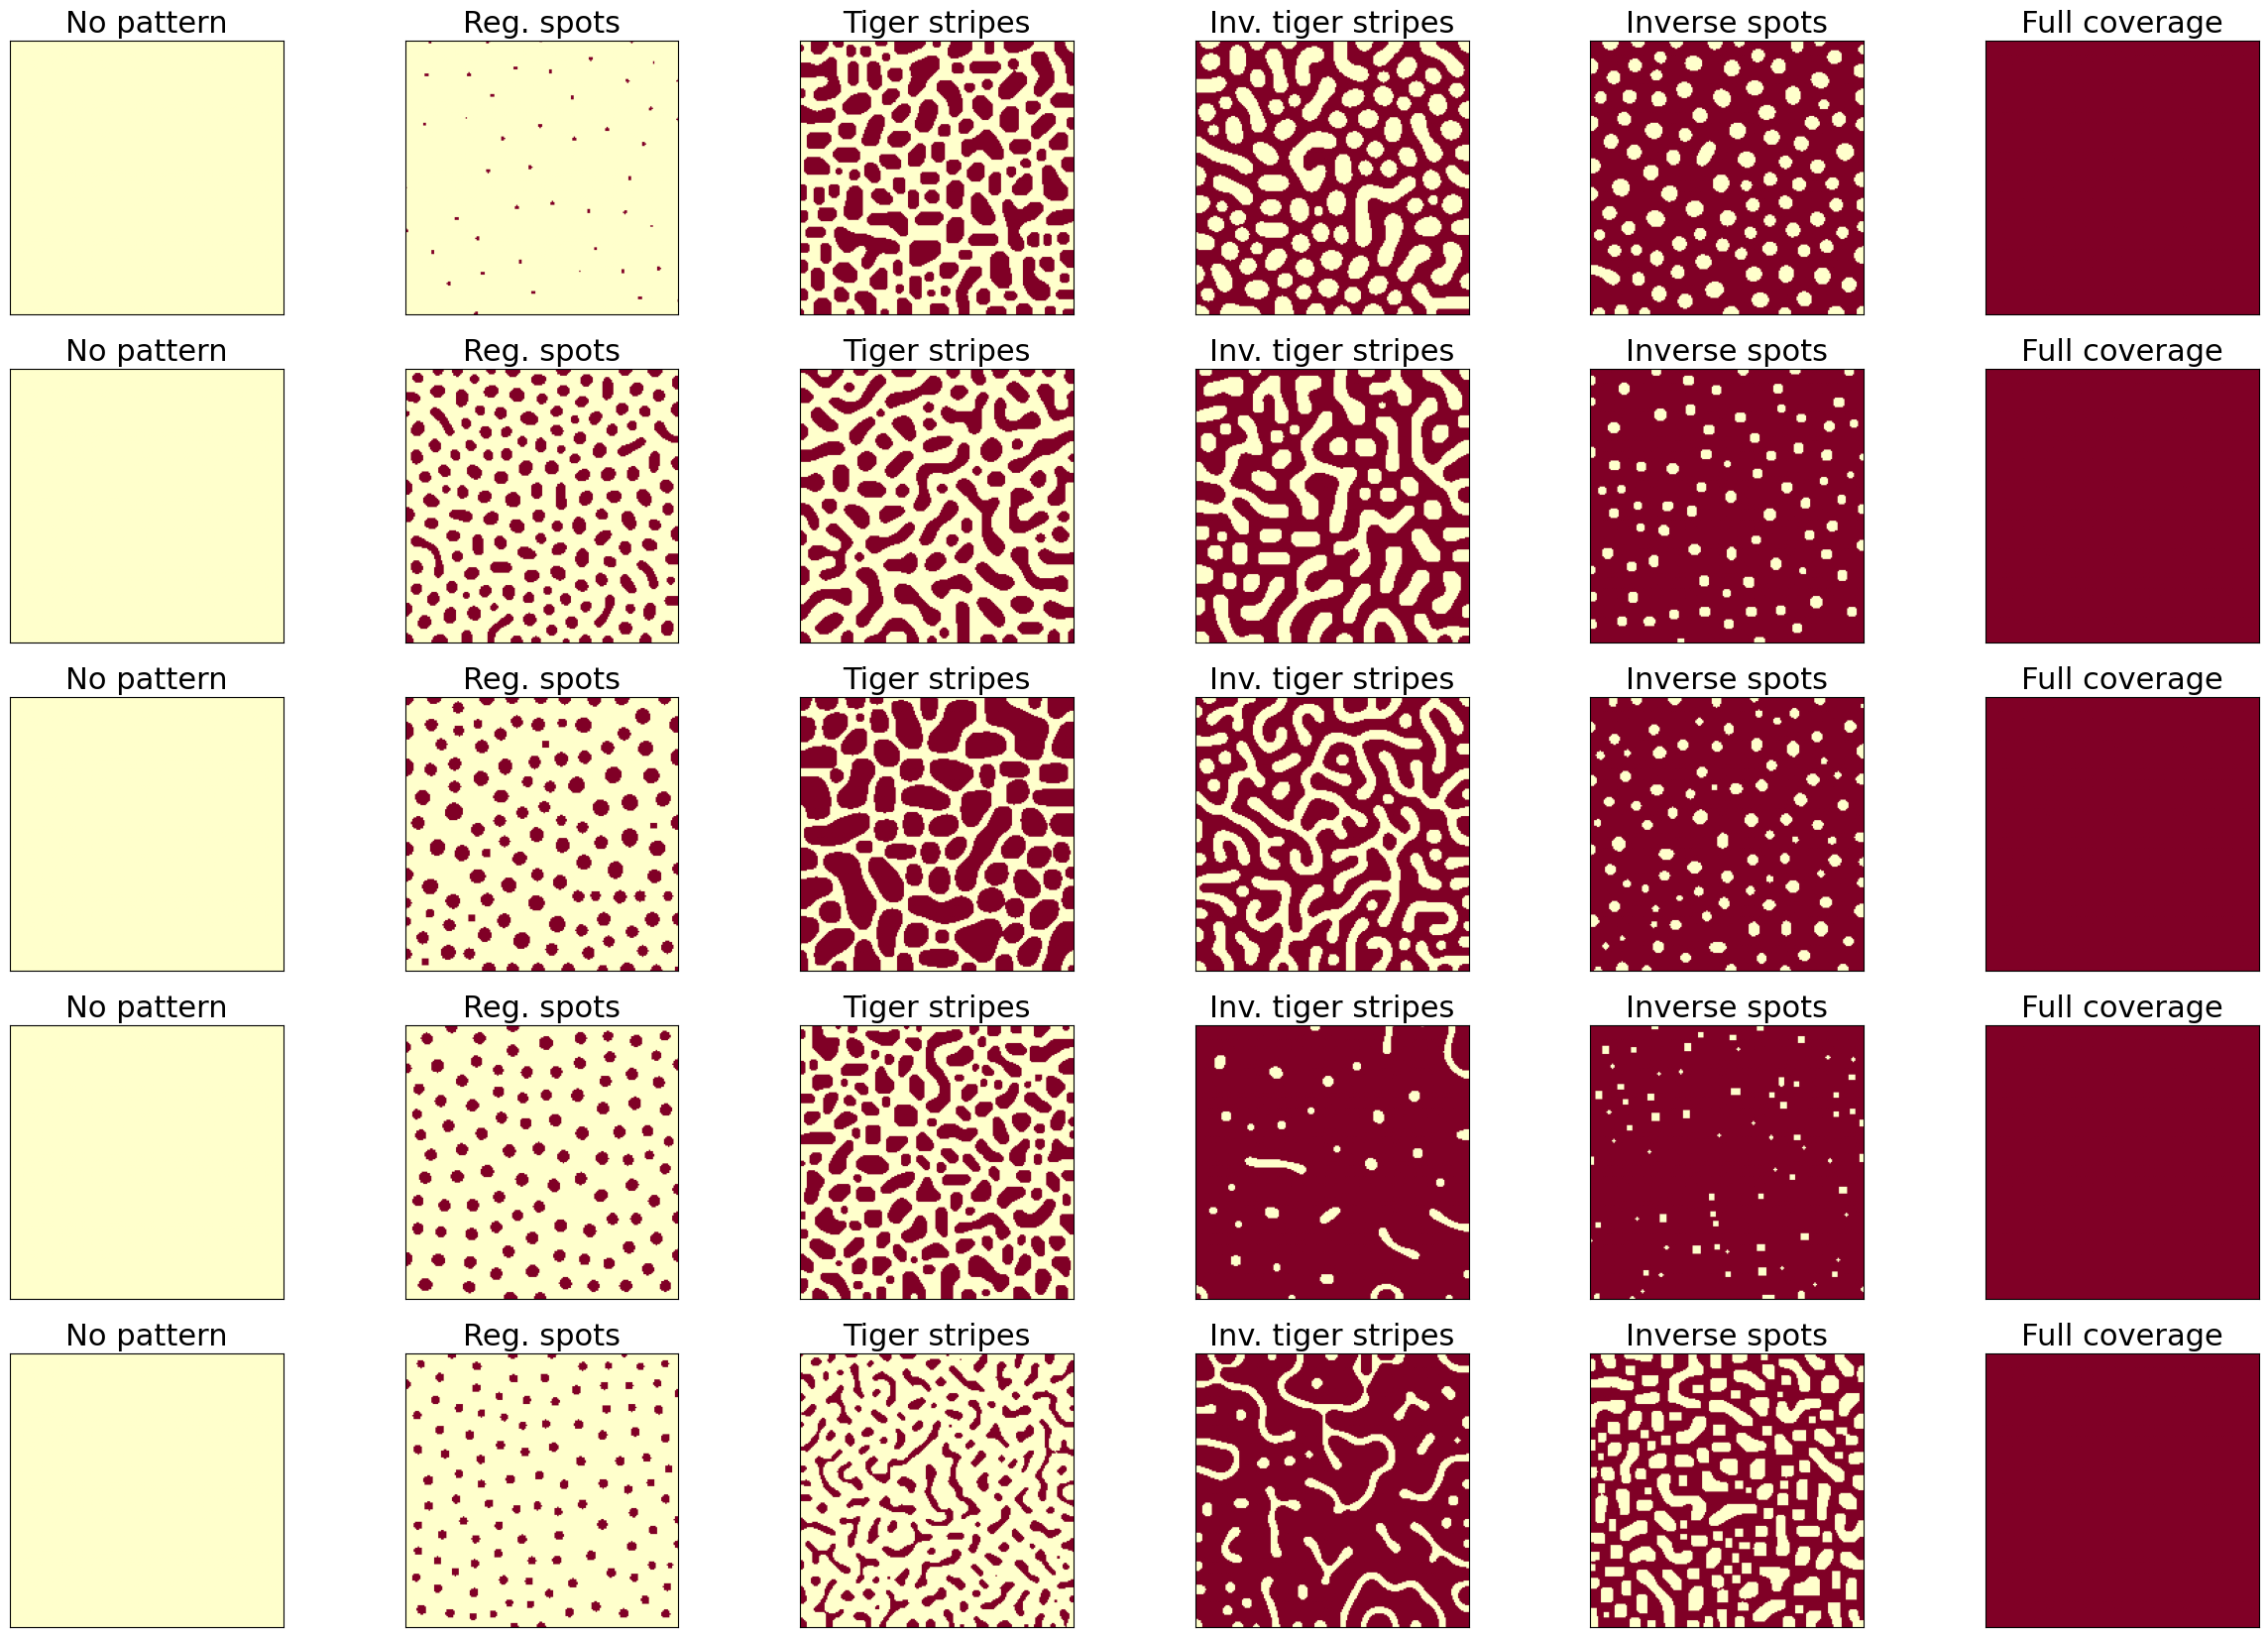

In [65]:
num_imgs = 5

if num_classes != presentation_order.__len__():
    print("Exiting: num_classes != presentation_order length")
    sys.exit()

fig, ax = plt.subplots(num_imgs, presentation_order.__len__())
#fig.suptitle('Classified Images From: ' + file_in, fontsize=36, y=0.97)
plt.subplots_adjust(top=0.75)

print_analytics = False

for i in range(num_imgs):
  #for j in range(len(class_dfs)):
  for col, j in enumerate(presentation_order):
    df = class_dfs[j]
    if df.shape[0] == 0:
      continue
    num = np.random.randint(low = 0, high= df.shape[0], size=1, dtype=int)[0]
    image_path = df["dir"][num] + df["path"][num]
    img = np.array(Image.open(image_path[1:]))
    ax[i][col].imshow(img, cmap = "YlOrRd", vmin = 0, vmax = 255)
    ax[i][col].set_title(presentation_names[col], fontsize = 22)
    ax[i][col].get_xaxis().set_visible(False)
    ax[i][col].get_yaxis().set_visible(False)

    if print_analytics: 
        plt.subplots_adjust(hspace=0.5)
        tr_val = round(df_analytics["tr"].iloc[num], 2)
        det_val = round(df_analytics["det"].iloc[num], 2)
        T1_val = round(df_analytics["T1"].iloc[num], 2)
        T2_val = round(df_analytics["T2"].iloc[num], 2)

        analytics_text = f"tr: {tr_val}   det: {det_val}\nT1: {T1_val}   T2: {T2_val}"
        ax[i][col].text(0.05, -0.22, analytics_text, transform=ax[i][col].transAxes, fontsize=16)

fig.set_figwidth(5*len(class_dfs))
fig.set_figheight(5 * num_imgs)

if print_analytics:
  plt.savefig(specific_file_dir + "ClassifiedImages_RandomImagesPerClass_cl" + str(num_classes) + ".png", dpi = 300, bbox_inches='tight')
plt.show()

In [66]:
# scaling data for correlation comparison
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

end_feats = feats_df.shape[1] -3
# feat_array_scaled contain only features (no image data)
feat_array_scaled = pd.DataFrame(sc.fit_transform(feats_df[feats_df.columns[13:end_feats]]))
print("shape of scaled feature array: ", feat_array_scaled.shape)

shape of scaled feature array:  (33770, 26)


In [67]:
feats_df.columns[13:end_feats]

Index(['num_spots', 'X_mean', 'Y_mean', 'Angle_mean', 'Circ._mean',
       '%Area_mean', '%Area_std', 'FeretAngle_mean', 'MinFeret_std', 'AR_std',
       'Round_std', 'Solidity_mean', 'Solidity_std', 'num_spots_inverted',
       'X_inverted_mean', 'Y_inverted_mean', 'Angle_inverted_mean',
       'IntDen_inverted_mean', '%Area_inverted_mean', '%Area_inverted_std',
       'FeretAngle_inverted_mean', 'MinFeret_inverted_std', 'AR_inverted_mean',
       'AR_inverted_std', 'Solidity_inverted_mean', 'Solidity_inverted_std'],
      dtype='object')

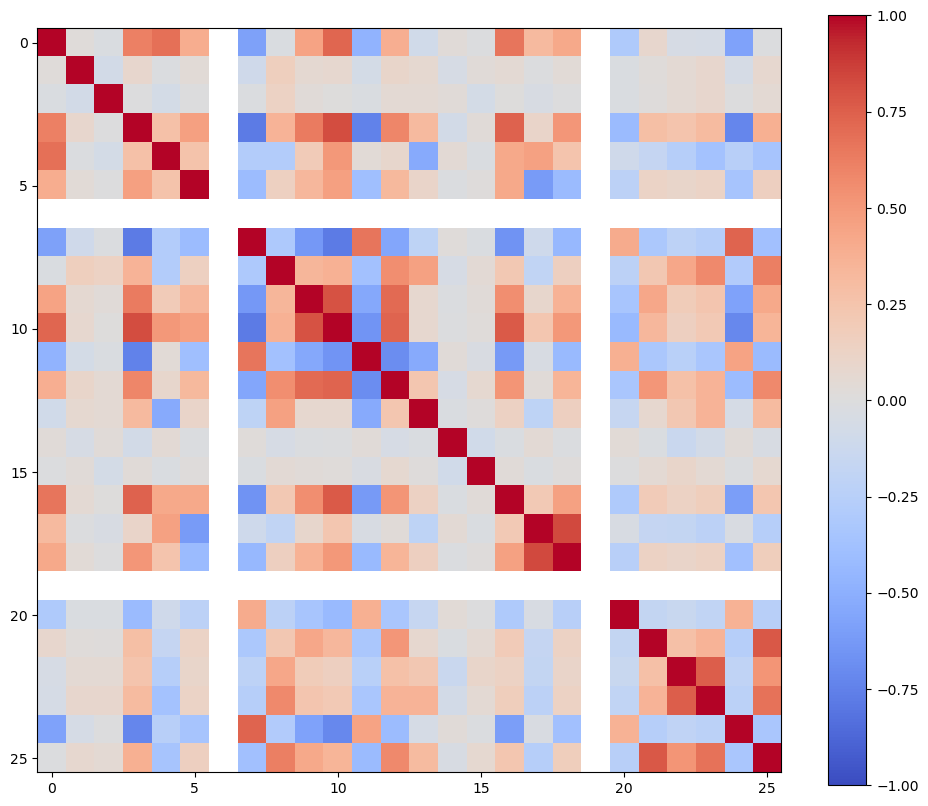

In [68]:
# testing correlation between features for PCA
correlation_matrix = feat_array_scaled.corr()
plt.figure(figsize=(12, 10))
plt.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()

In [69]:

# Applying PCA function
print("\n\nPCA on reduced dataframe:")
from sklearn.decomposition import PCA

pca = PCA(n_components = num_PCA_components)

pca_data = pca.fit_transform(feat_array_scaled)

explained_variance = pca.explained_variance_ratio_
print("\nExplained Variance: ", explained_variance)

# drop pc3 column if 2 components for less confusion
if num_PCA_components == 2 and "pc3" in feats_df.columns:
    feats_df.drop(columns = ["pc3"], inplace = True)

for j in range(num_PCA_components):
    feats_df["pc"+str(j+1)] = pca_data[:,j]

class_dfs = [df.copy() for df in class_dfs]
for i in range(num_classes):
    class_subset = feats_df[feats_df["cluster"] == i]
    for j in range(num_PCA_components):
        class_dfs[i].loc[:,"pc" + str(j+1)] = class_subset["pc" + str(j+1)].values

# PCA components (loadings)
loadings = pd.DataFrame(pca.components_.T,
                        columns=[f'PC{i+1}' for i in range(len(pca.components_))],
                        index=feat_array_scaled.columns)

print("\nPCA Loadings:")
print(loadings)

# Find top features for each principal component
top_features = {}
for pc in loadings.columns:
    top_features[pc] = loadings[pc].abs().nlargest(10).index.tolist()  # Top 3 contributing features
print("\nTop Contributing Features per Principal Component:")
print(top_features)

# print top features and their loadings for each PC
for j in range(num_PCA_components):
   print("PC" + str(j+1)+ ":")
   for feat in top_features["PC"+str(j+1)]:
       print(f"----{feats_df.columns[feat + 13]};   loading: {loadings.loc[feat, "PC" + str(j+1)]}")



PCA on reduced dataframe:

Explained Variance:  [0.32704176 0.15427178]

PCA Loadings:
        PC1      PC2
0   0.22685  0.30558
1   0.03897 -0.03951
2   0.01201 -0.05847
3   0.31841  0.06236
4   0.08073  0.43216
5   0.16080 -0.02644
6   0.00000 -0.00000
7  -0.30162 -0.07308
8   0.18178 -0.28121
9   0.27922  0.03315
10  0.32621  0.14914
11 -0.28610  0.04753
12  0.28441 -0.07482
13  0.10678 -0.26006
14 -0.02010  0.05186
15  0.01886 -0.04072
16  0.27727  0.15603
17  0.03240  0.33356
18  0.18516  0.18116
19 -0.00000  0.00000
20 -0.17893 -0.00665
21  0.16896 -0.19377
22  0.12938 -0.28872
23  0.15960 -0.34202
24 -0.26832 -0.08340
25  0.20697 -0.33073

Top Contributing Features per Principal Component:
{'PC1': [10, 3, 7, 11, 12, 9, 16, 24, 0, 25], 'PC2': [4, 23, 17, 25, 0, 22, 8, 13, 21, 18]}
PC1:
----Round_std;   loading: 0.3262132603216396
----Angle_mean;   loading: 0.3184078307645969
----FeretAngle_mean;   loading: -0.3016171579052605
----Solidity_mean;   loading: -0.2860960330001027
--

In [70]:
# will show PCA columns added to feats_df
feats_df.head()

,Ua,Ui,Ga,Gi,Ba,Da,Di,pattern,noise,path,seed,dir,feat_bool,num_spots,X_mean,Y_mean,Angle_mean,Circ._mean,%Area_mean,%Area_std,FeretAngle_mean,MinFeret_std,AR_std,Round_std,Solidity_mean,Solidity_std,num_spots_inverted,X_inverted_mean,Y_inverted_mean,Angle_inverted_mean,IntDen_inverted_mean,%Area_inverted_mean,%Area_inverted_std,FeretAngle_inverted_mean,MinFeret_inverted_std,AR_inverted_mean,AR_inverted_std,Solidity_inverted_mean,Solidity_inverted_std,pc1,pc2,cluster
0,0.02512,0.06382,0.07196,0.10633,-0.11313,0.00919,0.61187,1,2,1.png,1,/content/Images3/,1,70,99.39594,97.53023,55.10890,0.95869,100.00000,0.00000,120.12900,0.56478,0.18357,0.11537,0.87949,0.06714,1,99.99800,100.02200,38.79600,9980445.00000,100.00000,0.00000,45.00000,0.00000,1.00100,0.00000,0.97900,0.00000,2.25388,1.40257,0
1,0.03447,0.05996,0.08080,0.10037,-0.13258,0.00885,0.85408,1,2,3.png,3,/content/Images3/,1,63,101.80057,99.45127,56.04956,0.99962,100.00000,0.00000,120.19119,0.61353,0.22678,0.12798,0.95490,0.04641,1,99.99200,100.01500,72.38000,10003140.00000,100.00000,0.00000,135.00000,0.00000,1.00000,0.00000,0.98100,0.00000,1.32589,1.70848,0
2,0.02837,0.05791,0.07400,0.08078,-0.13379,0.00851,0.53424,1,2,7.png,7,/content/Images3/,1,77,100.55768,98.10334,29.22083,0.99297,100.00000,0.00000,133.45013,0.37595,0.22079,0.12952,0.94681,0.05097,1,99.98700,100.00100,5.76600,10012320.00000,100.00000,0.00000,45.00000,0.00000,1.00000,0.00000,0.98200,0.00000,1.27351,1.48869,0
3,0.03636,0.05572,0.08897,0.10772,-0.12676,0.01132,0.80970,1,2,11.png,11,/content/Images3/,1,60,100.27892,96.62343,31.87688,0.99860,100.00000,0.00000,121.10033,0.64010,0.25534,0.14752,0.87972,0.05249,1,99.99600,100.05800,126.21500,10042920.00000,100.00000,0.00000,135.00000,0.00000,1.00000,0.00000,0.98500,0.00000,1.90843,1.80442,0
4,0.03585,0.07876,0.07823,0.10148,-0.11575,0.01054,0.93389,1,2,12.png,12,/content/Images3/,1,73,103.19297,99.32097,58.91552,0.99763,100.00000,0.00000,110.34084,0.73139,0.18829,0.11005,0.91281,0.03712,1,99.97200,100.01500,57.70800,9882780.00000,100.00000,0.00000,135.00000,0.00000,1.00000,0.00000,0.96900,0.00000,1.54761,1.68752,0


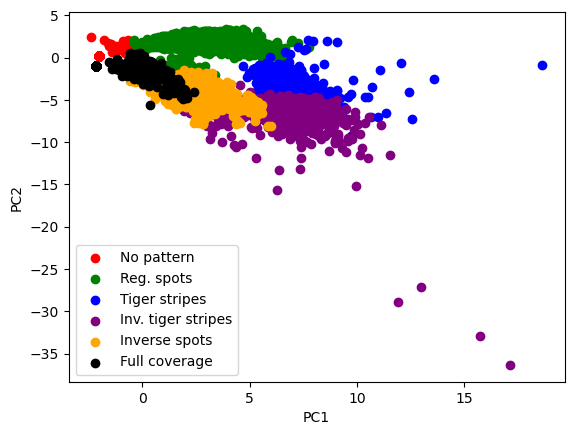

In [71]:
# plot the model predicted class in feature space
folder_name = "PCA_of_Features/"
os.makedirs(specific_file_dir + folder_name, exist_ok=True)

import plotly.graph_objects as go

feat_1 = "pc1"
feat_2 = "pc2"

alpha = [1,1,1,1,1,1,1,1,1,1]

if num_PCA_components == 2:
  fig, ax = plt.subplots()
  for i,j in enumerate(presentation_order):
    df = class_dfs[j]
    ax.scatter(df[feat_1], df[feat_2], c = colors[i], label = presentation_names[i], alpha = alpha[j])

  leg = ax.legend(loc="lower left")
  ax.set(xlabel = "PC1", ylabel = "PC2", title = "")

  # option_print = True
  if option_print:
    plt.savefig(specific_file_dir + folder_name + "PCA_of_Feats_2_Components.png", dpi = 300, bbox_inches='tight')
  plt.show()

Exploration of combos of points in 2D and 3D

In [72]:
# PCA on parameters
print("\n\nPCA on parameters:")
num_PCA_P_components = 2

# scaling data
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

# param_array_scaled contain only 7 paramaters
param_array_scaled = pd.DataFrame(sc.fit_transform(feats_df[feats_df.columns[0:7]]))
print(param_array_scaled.shape)

# Applying PCA function on training and testing set of X component
from sklearn.decomposition import PCA

pca_p = PCA(n_components = num_PCA_P_components)
pca_data_p = pca_p.fit_transform(param_array_scaled)

explained_variance_p = pca_p.explained_variance_ratio_
print(explained_variance_p)

# drop pcp3 column if 2 components for less confusion
if num_PCA_P_components == 2 and "pcp3" in feats_df.columns:
    feats_df.drop(columns = ["pcp3"], inplace = True)

for j in range(num_PCA_P_components):
    feats_df["pcp"+str(j+1)] = pca_data_p[:,j]

class_dfs = [df.copy() for df in class_dfs]
for i in range(num_classes):
    class_subset = feats_df[feats_df["cluster"] == i]
    for j in range(num_PCA_P_components):
        class_dfs[i].loc[:,"pcp" + str(j+1)] = class_subset["pcp" + str(j+1)].values

# PCA components (loadings)
loadings_p = pd.DataFrame(pca_p.components_.T,
                          columns=[f'PC{i+1}' for i in range(len(pca_p.components_))],
                          index=param_array_scaled.columns)

print("PCA in parameters space Loadings:")
print(loadings_p)

# Find top features for each principal component
top_parameters = {}
for pc in loadings_p.columns:
    top_parameters[pc] = loadings_p[pc].abs().nlargest(4).index.tolist() # Top 3 contributing features
print("\nTop Contributing Parameters per Principal Component:")
print(top_parameters)

for j in range(num_PCA_P_components):
    print("PC" + str(j+1)+ ":")
    for par in top_parameters["PC"+str(j+1)]:
        print(f"----{feats_df.columns[par]}")



PCA on parameters:
(33770, 7)
[0.1493331  0.14579587]
PCA in parameters space Loadings:
       PC1      PC2
0  0.03122  0.67889
1  0.59581 -0.19012
2  0.46567  0.24569
3  0.21267 -0.37576
4 -0.16441 -0.23971
5  0.00924  0.49337
6  0.59568  0.02285

Top Contributing Parameters per Principal Component:
{'PC1': [1, 6, 2, 3], 'PC2': [0, 5, 3, 2]}
PC1:
----Ui
----Di
----Ga
----Gi
PC2:
----Ua
----Da
----Gi
----Ga


In [73]:
feats_df.head()

,Ua,Ui,Ga,Gi,Ba,Da,Di,pattern,noise,path,seed,dir,feat_bool,num_spots,X_mean,Y_mean,Angle_mean,Circ._mean,%Area_mean,%Area_std,FeretAngle_mean,MinFeret_std,AR_std,Round_std,Solidity_mean,Solidity_std,num_spots_inverted,X_inverted_mean,Y_inverted_mean,Angle_inverted_mean,IntDen_inverted_mean,%Area_inverted_mean,%Area_inverted_std,FeretAngle_inverted_mean,MinFeret_inverted_std,AR_inverted_mean,AR_inverted_std,Solidity_inverted_mean,Solidity_inverted_std,pc1,pc2,cluster,pcp1,pcp2
0,0.02512,0.06382,0.07196,0.10633,-0.11313,0.00919,0.61187,1,2,1.png,1,/content/Images3/,1,70,99.39594,97.53023,55.10890,0.95869,100.00000,0.00000,120.12900,0.56478,0.18357,0.11537,0.87949,0.06714,1,99.99800,100.02200,38.79600,9980445.00000,100.00000,0.00000,45.00000,0.00000,1.00100,0.00000,0.97900,0.00000,2.25388,1.40257,0,-1.24885,-0.78079
1,0.03447,0.05996,0.08080,0.10037,-0.13258,0.00885,0.85408,1,2,3.png,3,/content/Images3/,1,63,101.80057,99.45127,56.04956,0.99962,100.00000,0.00000,120.19119,0.61353,0.22678,0.12798,0.95490,0.04641,1,99.99200,100.01500,72.38000,10003140.00000,100.00000,0.00000,135.00000,0.00000,1.00000,0.00000,0.98100,0.00000,1.32589,1.70848,0,-0.69388,-0.13287
2,0.02837,0.05791,0.07400,0.08078,-0.13379,0.00851,0.53424,1,2,7.png,7,/content/Images3/,1,77,100.55768,98.10334,29.22083,0.99297,100.00000,0.00000,133.45013,0.37595,0.22079,0.12952,0.94681,0.05097,1,99.98700,100.00100,5.76600,10012320.00000,100.00000,0.00000,45.00000,0.00000,1.00000,0.00000,0.98200,0.00000,1.27351,1.48869,0,-1.47987,-0.51952
3,0.03636,0.05572,0.08897,0.10772,-0.12676,0.01132,0.80970,1,2,11.png,11,/content/Images3/,1,60,100.27892,96.62343,31.87688,0.99860,100.00000,0.00000,121.10033,0.64010,0.25534,0.14752,0.87972,0.05249,1,99.99600,100.05800,126.21500,10042920.00000,100.00000,0.00000,135.00000,0.00000,1.00000,0.00000,0.98500,0.00000,1.90843,1.80442,0,-0.68140,1.07478
4,0.03585,0.07876,0.07823,0.10148,-0.11575,0.01054,0.93389,1,2,12.png,12,/content/Images3/,1,73,103.19297,99.32097,58.91552,0.99763,100.00000,0.00000,110.34084,0.73139,0.18829,0.11005,0.91281,0.03712,1,99.97200,100.01500,57.70800,9882780.00000,100.00000,0.00000,135.00000,0.00000,1.00000,0.00000,0.96900,0.00000,1.54761,1.68752,0,-0.41362,0.54307


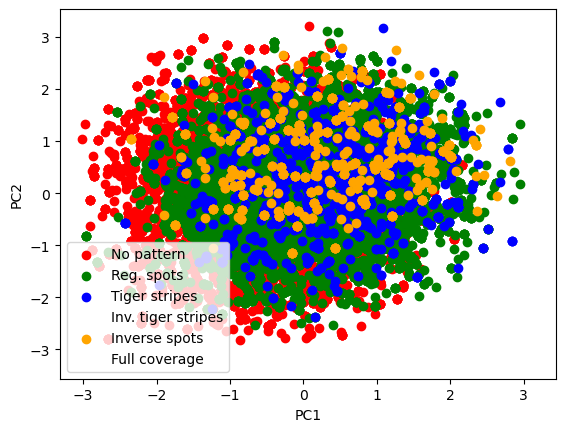

In [74]:
# plot the model predicted class in prameters space
folder_name = "PCA_of_Parameters/"
os.makedirs(specific_file_dir + folder_name, exist_ok=True)

import plotly.graph_objects as go

component_1 = "pcp1"
component_2 = "pcp2"

alpha = [1,0,1,0,1,1,1,1,1,1]


if num_PCA_P_components == 2:
    fig, ax = plt.subplots()
    for i,j in enumerate(presentation_order):
        df = class_dfs[j]
        ax.scatter(df[component_1], df[component_2], c = colors[i], label = presentation_names[i], alpha = alpha[j])

    leg = ax.legend(loc="lower left")
    ax.set(xlabel = "PC1", ylabel = "PC2", title = "")

    # option_print = True
    if option_print:
        plt.savefig(specific_file_dir + folder_name + "PCA_of_Params_2_Components.png", dpi = 300, bbox_inches='tight')
        plt.show()

if num_PCA_P_components == 3:
    component_3 = "pcp3"

    # 3D matplotlib plot
    fig = plt.figure(figsize=(8, 8))
    ax = plt.axes(projection='3d')

    for i,j in enumerate(presentation_order):
        df = class_dfs[j]
        ax.scatter3D(df[component_1], df[component_2], df[component_3], c = colors[i], label = presentation_names[i], alpha = alpha[j])

    leg = ax.legend(loc="upper left")
    ax.set(xlabel = component_1, ylabel = component_2, zlabel = component_3)
    ax.view_init(30,45)

    # enhanced 3D plot with plotly
    traces = []
    for i,j in enumerate(presentation_order):
        df = class_dfs[j]
        color = colors[j]
        cur_alpha = alpha[j]

        trace = go.Scatter3d(x=df[component_1],y=df[component_2],z=df[component_3], name=presentation_names[i], mode='markers',
            marker=dict(
                size=5,
                color=color,
                opacity=cur_alpha
            )
        )
        traces.append(trace)

    fig = go.Figure(data=traces)
    fig.update_layout(margin=dict(l=5, r=5, b=5, t=5))
    fig.update_layout(scene=dict(
            xaxis_title='PC1',
            yaxis_title='PC2',
            zaxis_title='PC3'
    ))
    # option_print = True
    if option_print:
        plt.savefig(specific_file_dir + folder_name + "PCA_of_Params_3_Components.png", dpi = 300, bbox_inches='tight')
        fig.write_html(specific_file_dir + folder_name + "Interactive_Plot_PCA_of_Params_3_Components.html")
        fig.show()

In [75]:
# change end_feats after adding pcp columns
end_feats = feats_df.shape[1] - 5
feats_df.columns[13:end_feats]

Index(['num_spots', 'X_mean', 'Y_mean', 'Angle_mean', 'Circ._mean',
       '%Area_mean', '%Area_std', 'FeretAngle_mean', 'MinFeret_std', 'AR_std',
       'Round_std', 'Solidity_mean', 'Solidity_std', 'num_spots_inverted',
       'X_inverted_mean', 'Y_inverted_mean', 'Angle_inverted_mean',
       'IntDen_inverted_mean', '%Area_inverted_mean', '%Area_inverted_std',
       'FeretAngle_inverted_mean', 'MinFeret_inverted_std', 'AR_inverted_mean',
       'AR_inverted_std', 'Solidity_inverted_mean', 'Solidity_inverted_std'],
      dtype='object')

In [76]:
# plot the model predicted class in feature space
print("\n\nNow plotting parameter vs parameter combinations: ")

folder_name = "Parameter_vs_Parameter_By_Class/"
os.makedirs(specific_file_dir + folder_name, exist_ok=True)

from itertools import combinations

def plotter(feat_1,feat_2):
  fig, ax = plt.subplots()

  alpha = [1,0,1,0,1,1,1,1,1,1] # opacity of points
  for i,j in enumerate(presentation_order):
    df = class_dfs[j]
    ax.scatter(df[feat_1], df[feat_2], c = colors[i], label = presentation_names[i], alpha = alpha[j])

  leg = ax.legend(loc="upper left")
  ax.set(title = feat_2 + " vs " + feat_1, xlabel = feat_1, ylabel = feat_2)

  # option_print = True
  if option_print:
    plt.savefig(specific_file_dir + folder_name + feat_1 + "_vs_" + feat_2 + ".png", dpi = 300)
    plt.close()
  else:
    plt.show()
  return

for p1,p2 in combinations(params, 2):
  plotter(p1,p2)

if option_print:
  print("2D Parameter plots are saved.")



Now plotting parameter vs parameter combinations: 
2D Parameter plots are saved.


In [77]:
# do clusters in 3 parameters in 3D
print("\n\nNow plotting parameter vs parameter vs parameter combinations: ")

folder_name = "Parameter_vs_Parameter_vs_Parameter_By_Class/"
os.makedirs(specific_file_dir + folder_name, exist_ok=True)

def threeD_plotter(feat_1,feat_2,feat_3):
    # 3D matplotlib plot
    fig = plt.figure(figsize=(8, 8))
    ax = plt.axes(projection='3d')

    alpha = [1,1,1,1,1,1,0]
    for i,j in enumerate(presentation_order):
      df = class_dfs[j]
      ax.scatter3D(df[feat_1], df[feat_2], df[feat_3], c = colors[i], label = presentation_names[i], alpha = alpha[j])

    leg = ax.legend(loc="upper left")
    ax.set(xlabel = feat_1, ylabel = feat_2, zlabel = feat_3)

    ax.view_init(30, 90)

    # enhanced 3D plot with plotly
    traces = []

    for i,j in enumerate(presentation_order):
      df = class_dfs[j]
      color = colors[j]
      cur_alpha = alpha[j]
    
      trace = go.Scatter3d(x=df[feat_1],y=df[feat_2],z=df[feat_3], name=presentation_names[i], mode='markers',
          marker=dict(
              size=5,
              color=color,
              opacity=cur_alpha
          ))
      traces.append(trace)

    fig = go.Figure(data=traces)
    fig.update_layout(margin=dict(l=5, r=5, b=5, t=5))
    #fig.show()
    
    option_print = True
    if option_print:
      plt.savefig(specific_file_dir + folder_name + feat_1 + "_vs_" + feat_2 + "_vs_" + feat_3 + ".png", dpi = 300, bbox_inches='tight')
      fig.write_html(specific_file_dir + folder_name + feat_1 + "_vs_" + feat_2 + "_vs_" + feat_3 + "_Interactive.html")
      plt.close()
    else:
      plt.show()

for p1,p2,p3 in combinations(params, 3):
  threeD_plotter(p1,p2,p3)

if option_print:
  print("3D Parameter plots are saved.")



Now plotting parameter vs parameter vs parameter combinations: 
3D Parameter plots are saved.


In [78]:
# plot ratios of params
print("\n\nNow plotting ratios of parameters: ")

folder_name = "Ratios_of_Parameters_By_Class/"
os.makedirs(specific_file_dir + folder_name, exist_ok=True)

def ratio_plotter(feat_1,feat_2):
  for p in range(num_classes):
    class_subset = feats_df[feats_df["cluster"] == p]
    class_dfs[p].loc[:, p0 + "/" + p1] = class_subset[p0 + "/" + p1].values
    class_dfs[p].loc[:, p2 + "/" + p3] = class_subset[p2 + "/" + p3].values

  fig, ax = plt.subplots()

  alpha = [1,0,1,0,1,1,1,1,1,1]
  for i,j in enumerate(presentation_order):
    df = class_dfs[j]
    ax.scatter(df[feat_1], df[feat_2], c = colors[i], label = presentation_names[i], alpha = alpha[j])

  leg = ax.legend(loc="upper left")
  ax.set(xlabel = feat_1, ylabel = feat_2)

  # option_print = True
  feat_1_name = feat_1.replace("/","-")
  feat_2_name = feat_2.replace("/","-")
  if option_print:
    plt.savefig(specific_file_dir + folder_name + feat_1_name + "_vs_" + feat_2_name + "_Ratios.png", dpi = 300, bbox_inches='tight')
    plt.close()
  else:
    plt.show()
  return

plot=1
counter = 0
for i in range(len(params)):
  for j in range(i,len(params)):
    for k in range(len(params)):
      for l in range(k,len(params)):
        p0 = params[i]
        p1 = params[j]
        p2 = params[k]
        p3 = params[l]

        if p0 != p1 and p1 != p2 and p2 != p3 and p1 != p3 and p0 != p3:
          ratio_1 = np.array(feats_df[p0]) / np.array(feats_df[p1])
          feats_df[p0 + "/" + p1] = ratio_1

          ratio_2 = np.array(feats_df[p2]) / np.array(feats_df[p3])
          feats_df[p2 + "/" + p3] = ratio_2
          class_dfs = [df.copy() for df in class_dfs]
          
          if plot:
            ratio_plotter(p0 + "/" + p1, p2 + "/" + p3)
          counter += 1
print(counter)

if option_print:
  print("Ratios of parameters plots are saved.")



Now plotting ratios of parameters: 
280
Ratios of parameters plots are saved.


In [79]:
# shows parameter ratio columns
ratio_start = feats_df.columns.get_loc("Ua/Ui")
ratio_end = feats_df.columns.get_loc("Ui/Ga") + 1

feats_df.columns[ratio_start:ratio_end]

Index(['Ua/Ui', 'Ua/Ga', 'Ua/Gi', 'Ua/Da', 'Ua/Di', 'Ua/Ba', 'Ga/Gi', 'Ga/Da',
       'Ga/Di', 'Ga/Ba', 'Gi/Da', 'Gi/Di', 'Gi/Ba', 'Da/Di', 'Da/Ba', 'Di/Ba',
       'Ui/Gi', 'Ui/Da', 'Ui/Di', 'Ui/Ba', 'Ui/Ga'],
      dtype='object')

In [80]:
# reset end_feats after adding ratio columns
end_feats = feats_df.shape[1] - (5 + len(feats_df.columns[ratio_start:ratio_end]))
feats_df.columns[13:end_feats]

Index(['num_spots', 'X_mean', 'Y_mean', 'Angle_mean', 'Circ._mean',
       '%Area_mean', '%Area_std', 'FeretAngle_mean', 'MinFeret_std', 'AR_std',
       'Round_std', 'Solidity_mean', 'Solidity_std', 'num_spots_inverted',
       'X_inverted_mean', 'Y_inverted_mean', 'Angle_inverted_mean',
       'IntDen_inverted_mean', '%Area_inverted_mean', '%Area_inverted_std',
       'FeretAngle_inverted_mean', 'MinFeret_inverted_std', 'AR_inverted_mean',
       'AR_inverted_std', 'Solidity_inverted_mean', 'Solidity_inverted_std'],
      dtype='object')

In [81]:
# print bar plots for each param based on class
print("\n\nNow plotting mean feature and parameter values by class: ")

folder_name = "Mean_Feat_Param_Values_By_Class/"
os.makedirs(specific_file_dir + folder_name, exist_ok=True)

feats = ["Ua","Ui","Ga","Gi","Da","Di","Ba",'Ua/Ui', 'Ua/Ga', 'Ua/Gi', 'Ua/Da', 'Ua/Di', 'Ua/Ba', 'Ga/Gi', 'Ga/Da',
       'Ga/Di', 'Ga/Ba', 'Gi/Da', 'Gi/Di', 'Gi/Ba', 'Da/Di', 'Da/Ba', 'Di/Ba',
       'Ui/Gi', 'Ui/Da', 'Ui/Di', 'Ui/Ba'] + list(feats_df.columns[13:end_feats])

classes = np.arange(0,num_classes)# list of unique clusters
rows = {str(i): [] for i in classes}

for i in range(len(feats)):
  fig, ax = plt.subplots()

  param = feats[i]
  data = []
  
  for i in presentation_order:
    df = class_dfs[i]
    rows[str(i)] = df[param].values
    data.append(rows[str(i)])

  positions = np.arange(0, num_classes) * 2.5

  # outliers not shown; to show outliers, set showfliers=True
  bp = ax.boxplot(data, widths=0.5, positions=positions, patch_artist=True, showfliers=False,
              medianprops=dict(color='black'))

  for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    
  ax.set(title = "Mean " + param)
  tick_labels = [i for i in presentation_names]
  ax.set_xticklabels(tick_labels)
  plt.xticks(fontsize=7.5)

  # option_print = True
  if option_print:
    if "/" in param:
      param = param.replace("/","-")
      param = param + "_Ratio"
    plt.savefig(specific_file_dir + folder_name + "Mean_" + param + ".png", dpi = 300,  bbox_inches='tight')
    plt.close()
  else:
    plt.show()
  
if option_print:
  print("Mean parameter box plots are saved.")



Now plotting mean feature and parameter values by class: 
Mean parameter box plots are saved.


In [82]:
# scale each param to plot them next to each other
from sklearn.preprocessing import MinMaxScaler

ratios = feats_df.columns[ratio_start:ratio_end]

params_df = feats_df[params]
for param in  params:
  sc = MinMaxScaler()
  param_arr = np.array(params_df[param]).reshape(-1,1)
  param_arr_scaled = sc.fit_transform(param_arr)
  feats_df[param + "_scaled"] = param_arr_scaled

feats_scaled_start = feats_df.columns.get_loc("Ua_scaled")
feats_scaled_end = feats_df.columns.get_loc("Ba_scaled") + 1
feats_scaled = feats_df.columns[feats_scaled_start:feats_scaled_end]

ratios_df = feats_df[ratios]
for ratio in  ratios:
  sc = MinMaxScaler()
  ratio_arr = np.array(ratios_df[ratio]).reshape(-1,1)
  ratio_arr_scaled = sc.fit_transform(ratio_arr)
  feats_df[ratio + "_scaled"] = ratio_arr_scaled

ratios_scaled_start = feats_df.columns.get_loc("Ua/Ui_scaled")
ratios_scaled_end = feats_df.columns.get_loc("Ui/Ga_scaled") + 1
ratios_scaled = feats_df.columns[ratios_scaled_start:ratios_scaled_end]

class_dfs = [df.copy() for df in class_dfs]
for i in range(num_classes):
    class_subset = feats_df[feats_df["cluster"] == i]
    for feat in feats_scaled:
        class_dfs[i].loc[:, feat] = class_subset[feat].values
    for ratio in ratios_scaled:
        class_dfs[i].loc[:, ratio] = class_subset[ratio].values



Now plotting a scaled ratio: 


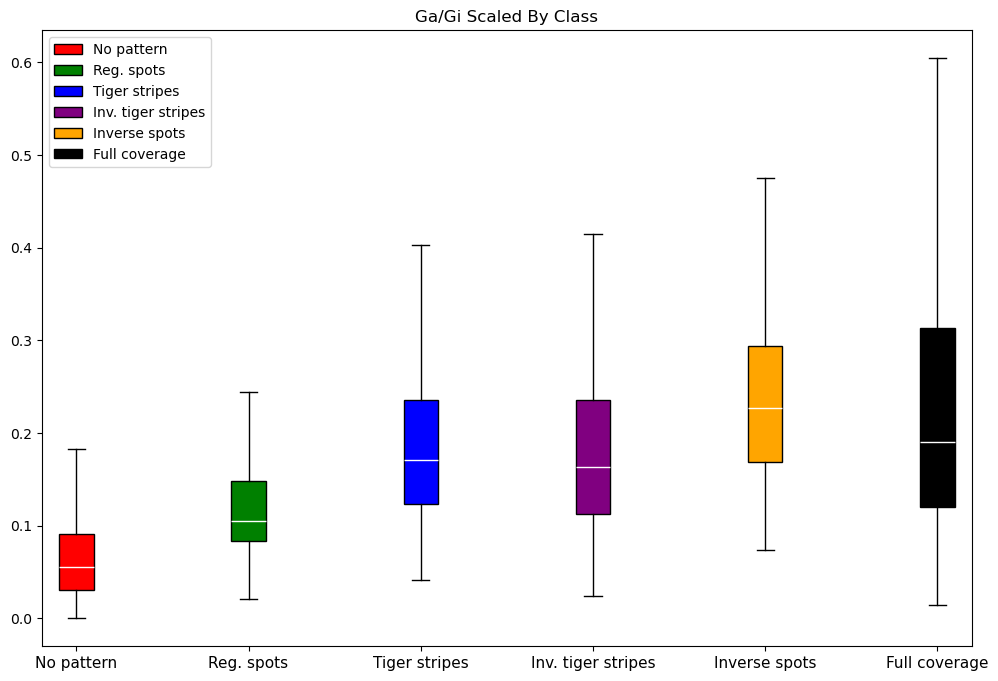

In [83]:
print("\n\nNow plotting a scaled ratio: ")

ratios_list = ["Ga/Gi_scaled"]

classes = np.arange(0,num_classes)# list of unique clusters
fig, ax = plt.subplots(figsize = (12,8))
data = []

for i in presentation_order:
  class_df = class_dfs[i]

  for feat in ratios_list:
    df = class_df[feat]
    data.append(df)

positions = np.arange(0, num_classes) * 2.5  + 1

# outliers not shown; to show outliers, set showfliers=True
bp = ax.boxplot(data, widths=0.5, positions=positions, patch_artist=True, showfliers=False,
            medianprops=dict(color='white'))

for patch, color in zip(bp['boxes'], colors):
  patch.set_facecolor(color)
    
ax.set(title = "Ga/Gi Scaled By Class")
ax.set_xticks(positions)
tick_labels = [i for i in presentation_names]
ax.set_xticklabels(tick_labels)
plt.xticks(fontsize=11)

leg = ax.legend(presentation_names, loc="upper left")
leg = ax.get_legend()

# option_print = True
if option_print:
  plt.savefig(specific_file_dir + "Scaled_Param_By_Class.png", dpi = 300, bbox_inches="tight")
plt.show()



Now plotting mean scaled parameter ratios by class: 


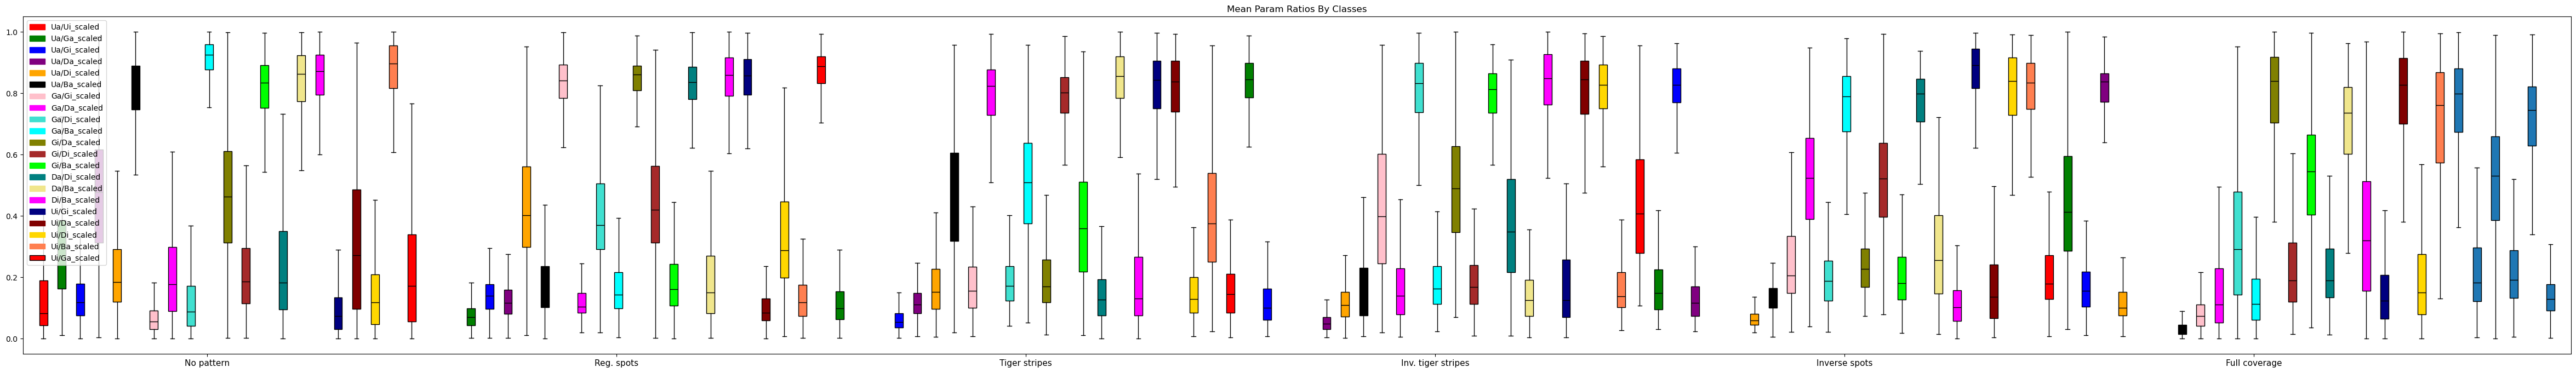

In [84]:
# print box plots for all scaled ratios based on class 
print("\n\nNow plotting mean scaled parameter ratios by class: ")

ratios_list = ratios_scaled.tolist()

classes = np.arange(0,num_classes)# list of unique clusters
fig, ax = plt.subplots(figsize = (60,8))
data = []

positions = np.arange(0, num_classes*len(ratios_list)) * .45
position_counter = 0

for i in presentation_order:
  class_df = class_dfs[i]

  for feat in ratios_list:
    df = class_df[feat]
    data.append(df)

    offset = position_counter // len(ratios_list)
    positions[position_counter] += offset
    position_counter += 1

# outliers not shown; to show outliers, set showfliers=True
bp = ax.boxplot(data, widths=0.2, positions=positions, patch_artist=True, showfliers=False,
            medianprops=dict(color='black'))

for patch, color in zip(bp['boxes'], colors*num_classes):
  patch.set_facecolor(color)
    
ax.set(title = "Mean Param Ratios By Classes")
xticks = [4+i*10 for i in range(len(presentation_order))]
ax.set_xticks(xticks)
tick_labels = [i for i in presentation_names]
ax.set_xticklabels(tick_labels)
plt.xticks(fontsize=11)

leg = ax.legend(ratios_list, loc="upper left")
leg = ax.get_legend()

for idx in range(len(colors)): 
    leg.legend_handles[idx].set_color(colors[idx])

# option_print = True
if option_print:
  plt.savefig(specific_file_dir + "Mean_All_Ratios_Scaled_By_Class.png", dpi = 300, bbox_inches="tight")
plt.show()



Now plotting mean scaled parameter values by class: 


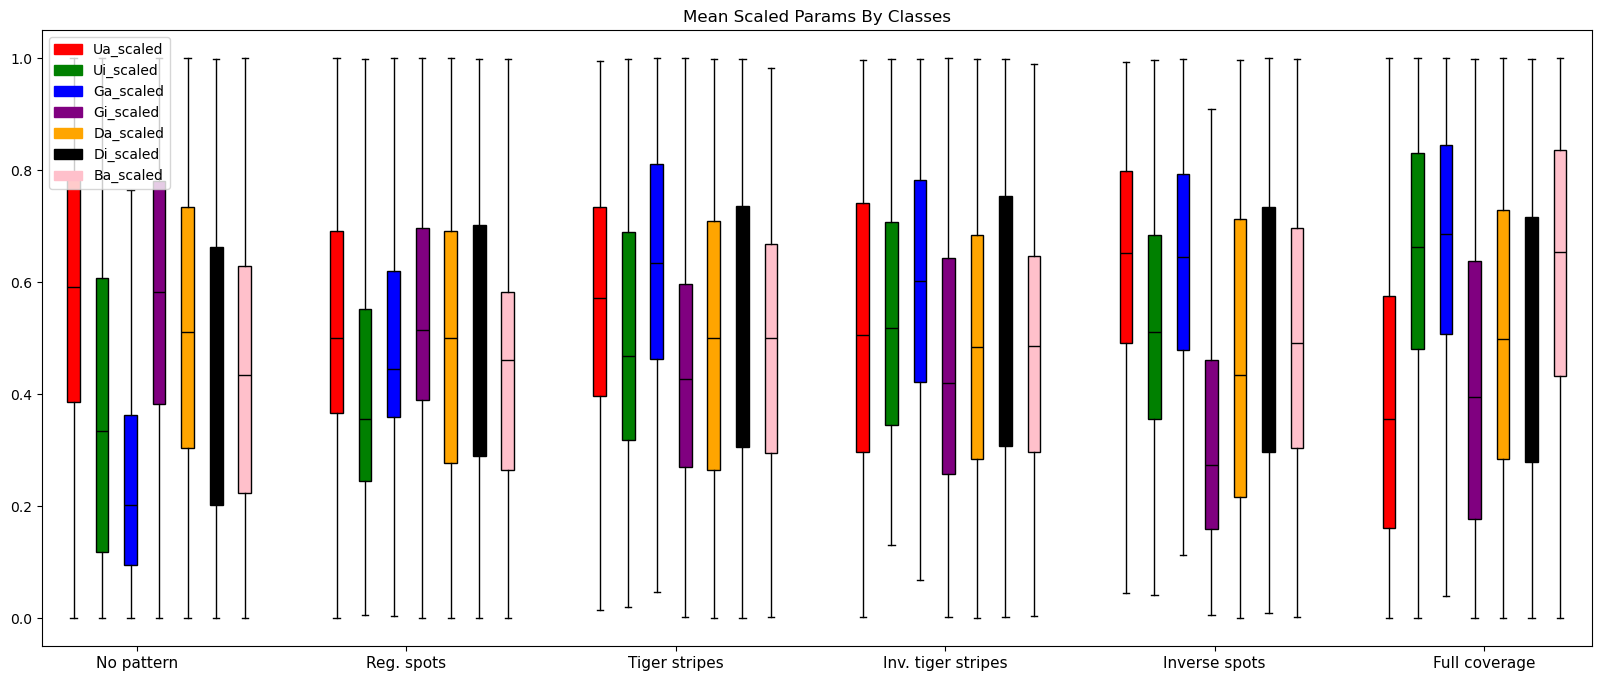

In [85]:
# print box plots for all 7 main params based on class 
print("\n\nNow plotting mean scaled parameter values by class: ")

feats_list = feats_scaled.tolist()

classes = np.arange(0,num_classes)# list of unique clusters
fig, ax = plt.subplots(figsize = (20,8))
data = []

positions = np.arange(0, len(feats_list)*num_classes) * 0.45

position_counter = 0
for i in presentation_order:
  class_df = class_dfs[i]

  for feat in feats_list:
    df = class_df[feat]
    data.append(df)

    offset = position_counter // len(feats_list)
    positions[position_counter] += offset
    position_counter += 1

# outliers not shown; to show outliers, set showfliers=True
bp = ax.boxplot(data, widths=0.2, positions=positions, patch_artist=True, showfliers=False,
            medianprops=dict(color='black'))

colors = [colors[i] for i in range(len(feats_list))]
for patch, color in zip(bp['boxes'], colors*num_classes):
  patch.set_facecolor(color)
    
ax.set(title = "Mean Scaled Params By Classes")
xticks = [1+i*4.25 for i in range(len(presentation_order))]
ax.set_xticks(xticks)
tick_labels = [i for i in presentation_names]
ax.set_xticklabels(tick_labels)
plt.xticks(fontsize=11)

leg = ax.legend(feats_list, loc="upper left")
leg = ax.get_legend()

for idx in range(len(colors)): 
    leg.legend_handles[idx].set_color(colors[idx])

# option_print = True
if option_print:
  plt.savefig(specific_file_dir + "Mean_All_Params_Scaled_By_Class.png", dpi = 300, bbox_inches="tight")
plt.show()

In [86]:
from sklearn.linear_model import LinearRegression

feat_1 = np.array(feats_df["num_spots"]).reshape(-1,1)
param_1 = np.array(feats_df["Ua"]).reshape(-1,1)

lin_reg=LinearRegression()
lin_reg.fit(feat_1,param_1)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [87]:
model = LinearRegression()

 #define predictor and response variables
feat_1 = np.array(feats_df["num_spots"]).reshape(-1,1)
param_1 = np.array(feats_df["Ua"]).reshape(-1,1)

# fit linear regression model
model.fit(param_1, feat_1)

#calculate R-squared (value indicating how well the data fits the regression model)
r_squared = model.score(param_1, feat_1)
print(r_squared)

0.026685643102544843


In [88]:
# update end_feats after adding scaled columns


end_feats = feats_df.shape[1] - (5 + len(feats_df.columns[ratio_start:ratio_end]) + len(feats_df.columns[feats_scaled_start:feats_scaled_end]) + len(feats_df.columns[ratios_scaled_start:ratios_scaled_end]))
feats_df.columns[13:end_feats]

Index(['num_spots', 'X_mean', 'Y_mean', 'Angle_mean', 'Circ._mean',
       '%Area_mean', '%Area_std', 'FeretAngle_mean', 'MinFeret_std', 'AR_std',
       'Round_std', 'Solidity_mean', 'Solidity_std', 'num_spots_inverted',
       'X_inverted_mean', 'Y_inverted_mean', 'Angle_inverted_mean',
       'IntDen_inverted_mean', '%Area_inverted_mean', '%Area_inverted_std',
       'FeretAngle_inverted_mean', 'MinFeret_inverted_std', 'AR_inverted_mean',
       'AR_inverted_std', 'Solidity_inverted_mean', 'Solidity_inverted_std'],
      dtype='object')

In [89]:
# calculate R-squared value for all features vs all params
all_params = ["Ua","Ui","Ga","Gi","Da","Di","Ba",'Ua/Ui', 'Ua/Ga', 'Ua/Gi', 'Ua/Da', 'Ua/Di', 'Ua/Ba', 'Ga/Gi', 'Ga/Da',
       'Ga/Di', 'Ga/Ba', 'Gi/Da', 'Gi/Di', 'Gi/Ba', 'Da/Di', 'Da/Ba', 'Di/Ba',
       'Ui/Gi', 'Ui/Da', 'Ui/Di', 'Ui/Ba']
feats = list(feats_df.columns[13:end_feats])

p_list = []
f_list = []
r2 = []

for param in all_params:
  for feat in feats:
    model = LinearRegression()

    feat_1 = np.array(feats_df[feat]).reshape(-1,1)
    param_1 = np.array(feats_df[param]).reshape(-1,1)

    model.fit(param_1, feat_1)

    r_squared = model.score(param_1, feat_1)

    r2.append(r_squared)
    p_list.append(param)
    f_list.append(feat)

r2_dic = {"feat": f_list,"param":p_list,"r2":r2}
r2_df = pd.DataFrame(r2_dic)
r2_df.head()

,feat,param,r2
0,num_spots,Ua,0.02669
1,X_mean,Ua,0.00032
2,Y_mean,Ua,0.00000
3,Angle_mean,Ua,0.00412
4,Circ._mean,Ua,0.00095


In [90]:
output_dir = specific_file_dir + "R2_Values/"
os.makedirs(output_dir, exist_ok=True)

# prints highest to lowest R-squared values for given feature
r2_sorted = r2_df.sort_values(by=['r2'], ascending = False)

# save full list of R2 values in descending order
pd.set_option('display.float_format', '{:.05f}'.format)
print(r2_sorted.to_string(index=False))
r2_sorted.to_csv(output_dir + "Feature_Param_R2.txt", sep='\t', index=False, header=True)

# save R2 values in descending order for each param in separate files
folder_name = "R2_Values_By_Param/"
os.makedirs(output_dir + folder_name, exist_ok=True)

for param in all_params:
    r2_param = r2_sorted[r2_sorted["param"] == param]
    r2_param = r2_param.reset_index(drop = True)
    r2_param.to_csv(output_dir + folder_name + param.replace("/","-") + "_R2.txt", sep='\t', index=False, header=True)

# save R2 values in descending order for each feature in separate files
folder_name = "R2_Values_By_Feature/"
os.makedirs(output_dir + folder_name, exist_ok=True)

for feat in feats:
    r2_feat = r2_sorted[r2_sorted["feat"] == feat]
    r2_feat = r2_feat.reset_index(drop = True)
    r2_feat.to_csv(output_dir + folder_name + feat + "_R2.txt", sep='\t', index=False, header=True)

                    feat param      r2
      %Area_inverted_std Da/Di 1.00000
      %Area_inverted_std    Ba 1.00000
               %Area_std    Gi 1.00000
      %Area_inverted_std Ui/Gi 1.00000
               %Area_std Ga/Di 1.00000
               %Area_std Ua/Ui 1.00000
      %Area_inverted_std Ga/Da 1.00000
               %Area_std Ui/Da 1.00000
      %Area_inverted_std    Ga 1.00000
               %Area_std Ga/Da 1.00000
      %Area_inverted_std Gi/Ba 1.00000
      %Area_inverted_std Ua/Ui 1.00000
      %Area_inverted_std Ga/Gi 1.00000
               %Area_std    Ga 1.00000
               %Area_std Ga/Gi 1.00000
      %Area_inverted_std Ui/Da 1.00000
               %Area_std Ua/Ga 1.00000
               %Area_std Ui/Di 1.00000
      %Area_inverted_std Ua/Ba 1.00000
      %Area_inverted_std Ga/Di 1.00000
               %Area_std Ga/Ba 1.00000
      %Area_inverted_std    Ui 1.00000
               %Area_std Ui/Gi 1.00000
               %Area_std    Di 1.00000
               %Area_std 

In [91]:
# plot the model predicted class in feature space
print("\n\nNow plotting parameters by class in the feature space: ")

folder_name = "Param_By_Class_in_Feature_Space/"
os.makedirs(specific_file_dir + folder_name, exist_ok=True)

image_features = list(feats_df.columns[13:end_feats])

classes = np.arange(0,num_classes)

for feat in image_features:
  for param in params:
    feat_1 = feat
    feat_2 = param

    fig, ax = plt.subplots()

    alpha = [1,1,1,1,1,1,1,1,1,1]
    for i,j in enumerate(presentation_order):
      df = class_dfs[j]
      ax.scatter(df[feat_1], df[feat_2], c = colors[i], label = presentation_names[i], alpha = alpha[j])

    leg = ax.legend(loc="upper left")
    ax.set(xlabel = feat_1, ylabel = feat_2)

    # option_print = True
    if "/" in feat_2:
      feat_2 = feat_2.replace("/","-")
    if option_print:
      plt.savefig(specific_file_dir + folder_name + feat_1 + "_vs_" + feat_2 + ".png", dpi = 300, bbox_inches="tight")
      plt.close()
    else:
      plt.show()

if option_print:
  print("Parameters in feature space plots are saved.")



Now plotting parameters by class in the feature space: 
Parameters in feature space plots are saved.
